<div style="text-align:center;">
  <h1 size=10>
    <b>BIG DATA ANALYTICS PROJECT</b><br>
    <b>Money Laundring Detection - IBM Transactions</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 26**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:** https://github.com/mariamiguel720/Big-Data-Analytics-Project-25-26

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Data Exploration](#4)
    - [4.1. Missing Values](#4_1)
    - [4.2. Duplicates](#4_2)
    - [4.3. Is Laundering Class Imbalance](#4_3)
    - [4.4. Categorical Variables](#4_4)
    - [4.5. Numeric Variables](#4_5)
- [5. Data Preprocessing](#5)
- [6. Graphframes](#6)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

This project focuses on money laundring detecting and uses the dataset IBM Transactions for Anti Money Laundering (HI-Small-Trans.csv) which contains approximately 5 million transactions with 11 features. GraphFrames and Streaming tecnhniques will be employed.

# <font color='#2f94d7' size=6>**2. Setup & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [ ]:
#!pip install "pyspark==3.5.0" 

In [2]:
# INSTALL JAVA 17

!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless
!java -version

Get:1 https://packages.cloud.google.com/apt cloud-sdk InRelease [1621 B]
Get:2 https://download.docker.com/linux/ubuntu noble InRelease [48.5 kB]       
Get:3 https://cli.github.com/packages stable InRelease [3917 B]                
0% [Connecting to archive.ubuntu.com]                                          

Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]       
Get:5 https://packages.cloud.google.com/apt cloud-sdk/main all Packages [2018 kB]
Get:6 https://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]     
Get:7 https://archive.ubuntu.com/ubuntu noble InRelease [256 kB]               
Hit:8 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Get:9 https://download.docker.com/linux/ubuntu noble/stable amd64 Packages [67.3 kB]
Get:10 https://download.docker.com/linux/ubuntu noble/stable amd64 Contents (deb) [1637 B]
Get:11 https://packages.cloud.google.com/apt cloud-sdk/main amd64 Packages [4754 kB]
Get:12 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:13 https://cloud.archive.ubuntu.com/ubuntu noble InRelease [256 kB]        
Get:14 https://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]      
Get:15 https://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]    
Get:16 ht

In [3]:
%pip install graphframes-py==0.10.0

Note: you may need to restart the kernel to use updated packages.


In [4]:
# IMPORT LIBRARIES
import os

# import the package we just installed
from graphframes import *

# import data types - All data types of Spark SQL are located in the package of pyspark.sql.types
from pyspark.sql.types import *

# Row can be used to create a row object by using named arguments
from pyspark.sql import Row

from pyspark.sql.functions import col

from pyspark.sql import SparkSession

from pyspark.sql import functions as F
from pyspark.sql.window import Window

import matplotlib.pyplot as plt

from itertools import chain
from pyspark.sql.functions import create_map, lit

In [5]:
# SET JAVA_HOME AND INITIALIZE SPARK SESSION
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

spark = (
    SparkSession.builder
    .master("local[*]")          
    .appName("GraphFrames-AML")
    .config("spark.jars.packages", "io.graphframes:graphframes-spark3_2.12:0.10.0")
    .config("spark.driver.memory", "6g")                               
    .config("spark.sql.shuffle.partitions", "8")                                       
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN") 
print(f"Spark version: {spark.version}")

:: loading settings :: url = jar:file:/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/zeus/.ivy2/cache
The jars for the packages stored in: /home/zeus/.ivy2/jars
io.graphframes#graphframes-spark3_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-58347873-d91e-4d98-bf02-1733f4ed2436;1.0
	confs: [default]
	found io.graphframes#graphframes-spark3_2.12;0.10.0 in central
	found io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 in central
:: resolution report :: resolve 189ms :: artifacts dl 15ms
	:: modules in use:
	io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 from central in [default]
	io.graphframes#graphframes-spark3_2.12;0.10.0 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   || 

Spark version: 3.5.0


In [6]:
sc = spark.sparkContext

# GraphFrames connected components requires a checkpoint directory
sc.setCheckpointDir("/tmp/graphframes-checkpoints")

spark.conf.set("spark.sql.shuffle.partitions", "16")

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [7]:
DATA_DIR = "../../data/IBM_Transactions/HI-Small_Trans.csv"

df = spark.read.csv(DATA_DIR, header = True, inferSchema = True, multiLine = True, escape = '"')

print("Loaded file.")
print(f"Data size: ({df.count()}, {len(df.columns)})")

Loaded file.


Data size: (5078345, 11)


The dataset has approximately 5 million records and 11 features

# <font color='#2f94d7' size=6>**4. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [8]:
df.printSchema()

root
 |-- Timestamp: string (nullable = true)
 |-- From Bank: integer (nullable = true)
 |-- Account2: string (nullable = true)
 |-- To Bank: integer (nullable = true)
 |-- Account4: string (nullable = true)
 |-- Amount Received: double (nullable = true)
 |-- Receiving Currency: string (nullable = true)
 |-- Amount Paid: double (nullable = true)
 |-- Payment Currency: string (nullable = true)
 |-- Payment Format: string (nullable = true)
 |-- Is Laundering: integer (nullable = true)



Timestamp has to be converted to the timestamp, the other columns seem to be in the correct format. nullable = True means that the columns can accept null values

In [9]:
df.show(10)

26/05/28 18:19:59 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Timestamp, From Bank, Account, To Bank, Account, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
 Schema: Timestamp, From Bank, Account2, To Bank, Account4, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|       Timestamp|From Bank| Account2|To Bank| Account4|Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|
+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|2022/09/01 00:20|       10|8000EBD30|     10|8000EBD30|        3697.34|         US Dollar|    3697.34|       US Dollar|  Reinvestment|            0|
|2022/09/01 00:20|     3208|8000F4580|      1|8000F5340|           0.01|         US Dollar|       0.01|       US Dollar|        Cheque|            0|
|2022/09/01 00:00|     3209|8000F4670|   3209|8000F4670|       14675.57|         US Dollar|   14675.57|       US Dollar|  Reinvestment|            0|
|2022/09/01 00:02|       12|8000F5030|     12|8000F5030|        2806.97|         US Dollar|    2806.

Spark is giving a warning about having 2 columns with the same name, "Account". Spark renames it to "Account2", "Account4". Let's rename the columns for a more clean and understandable way.

In [10]:
# RENAME COLUMNS
df = df.withColumnRenamed("Account2", "src_account") \
       .withColumnRenamed("Account4", "dst_account") \
       .withColumnRenamed("From Bank", "from_bank") \
       .withColumnRenamed("To Bank", "to_bank") \
       .withColumnRenamed("Amount Received", "amount_received") \
       .withColumnRenamed("Amount Paid", "amount_paid") \
       .withColumnRenamed("Receiving Currency", "recv_currency") \
       .withColumnRenamed("Payment Currency", "pay_currency") \
       .withColumnRenamed("Payment Format", "pay_format") \
       .withColumnRenamed("Is Laundering", "is_laundering")

In [11]:
print("Time Period")
print("=" * 50)
df.select(
    F.min("Timestamp").alias("start"),
    F.max("Timestamp").alias("end")
).show()

Time Period


+----------------+----------------+
|           start|             end|
+----------------+----------------+
|2022/09/01 00:00|2022/09/18 16:18|
+----------------+----------------+



The transactions go from 01/09/2022 to 18/09/2022, consisting of only 18 days.

# <font color='#2f94d7' size=5>**4.1. Missing Values**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

In [12]:
# CHECK FOR NULL VALUES
print("NULL VALUES PER COLUMN")
print("=" * 50)
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

NULL VALUES PER COLUMN


26/05/28 18:20:07 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Timestamp, From Bank, Account, To Bank, Account, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
 Schema: Timestamp, From Bank, Account2, To Bank, Account4, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


+---------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+
|Timestamp|from_bank|src_account|to_bank|dst_account|amount_received|recv_currency|amount_paid|pay_currency|pay_format|is_laundering|
+---------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+
|        0|        0|          0|      0|          0|              0|            0|          0|           0|         0|            0|
+---------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+



# <font color='#2f94d7' size=5>**4.2. Duplicates**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

In [13]:
print("DUPLICATES")
print("=" * 50)
total = df.count()
distinct_rows = df.dropDuplicates().count()
print(f"Total nr of rows    : {total:,}")
print(f"Nr of unique rows   : {distinct_rows:,}")
print(f"Nr of duplicates    : {total - distinct_rows:,}")

DUPLICATES


26/05/28 18:20:18 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Timestamp, From Bank, Account, To Bank, Account, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
 Schema: Timestamp, From Bank, Account2, To Bank, Account4, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


Total nr of rows    : 5,078,345
Nr of unique rows   : 5,078,336
Nr of duplicates    : 9


In [14]:
# Encontrar as linhas que aparecem mais do que uma vez
duplicates = df.groupBy(df.columns).count().filter(F.col("count") > 1)
# groups all rows that have the same values in every column and counts how many times it happens, then filters for the groups 
# more than 1 distinct row

print(f"Duplicated groups: {duplicates.count()}")
duplicates.show(truncate=False)

26/05/28 18:20:47 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Timestamp, From Bank, Account, To Bank, Account, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
 Schema: Timestamp, From Bank, Account2, To Bank, Account4, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv
26/05/28 18:21:09 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Timestamp, From Bank, Account, To Bank, Account, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
 Schema: Timestamp, From Bank, Account2, To Bank, Account4, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
Expected: Account2 but found: Account
CSV fi

Duplicated groups: 9


+----------------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+-----+
|Timestamp       |from_bank|src_account|to_bank|dst_account|amount_received|recv_currency|amount_paid|pay_currency|pay_format|is_laundering|count|
+----------------+---------+-----------+-------+-----------+---------------+-------------+-----------+------------+----------+-------------+-----+
|2022/09/07 21:25|29992    |8099A29B1  |220    |813725AE1  |3.0E-6         |Bitcoin      |3.0E-6     |Bitcoin     |Bitcoin   |0            |2    |
|2022/09/01 16:20|12004    |800C927C1  |12004  |800C927C0  |8.0E-6         |Bitcoin      |0.08       |Euro        |ACH       |0            |2    |
|2022/09/01 16:20|12004    |800C927C1  |220    |813D8C1E1  |8.0E-6         |Bitcoin      |8.0E-6     |Bitcoin     |Bitcoin   |0            |2    |
|2022/09/09 10:03|6075     |80C702911  |6075   |80C702910  |2.0E-6         |Bitcoin      |0.02       |US Dollar   |ACH

9 duplicates were found. The number is very small when compared to the size of the dataset, the best practice is too remove these 9 rows. 

# <font color='#2f94d7' size=5>**4.3. Is Laundring Class Imbalance**</font> <a class="anchor" id="4_3"></a>

[Back to TOC](#toc)

In [15]:
# CHECK FOR IS LAUNDERING CLASS IMBALANCE
print("DISTRIBUTION OF IS LAUNDERING")
print("=" * 50)
df.groupBy("is_laundering").count() \
  .withColumn("percentage", F.round(F.col("count") / total * 100, 2)) \
  .orderBy("is_laundering").show()

DISTRIBUTION OF IS LAUNDERING


+-------------+-------+----------+
|is_laundering|  count|percentage|
+-------------+-------+----------+
|            0|5073168|      99.9|
|            1|   5177|       0.1|
+-------------+-------+----------+



Only 0.1% of the transactions is money laundering, this is an expected class imbalance for this type of data.

# <font color='#2f94d7' size=5>**4.4. Categorical Variables**</font> <a class="anchor" id="4_4"></a>

[Back to TOC](#toc)

In [16]:
# CHECK FOR THE DIFFERENT CURRENCIES
df.groupBy("pay_currency") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(truncate=False)

+-----------------+-------+
|pay_currency     |count  |
+-----------------+-------+
|US Dollar        |1895172|
|Euro             |1168297|
|Swiss Franc      |234860 |
|Yuan             |213752 |
|Shekel           |192184 |
|Rupee            |190202 |
|UK Pound         |180738 |
|Yen              |155209 |
|Ruble            |155178 |
|Bitcoin          |146066 |
|Canadian Dollar  |140042 |
|Australian Dollar|136769 |
|Mexican Peso     |110159 |
|Saudi Riyal      |89014  |
|Brazil Real      |70703  |
+-----------------+-------+



In [17]:
# CHECK FOR THE DIFFERENT CURRENCIES
df.groupBy("recv_currency") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(truncate=False)

+-----------------+-------+
|recv_currency    |count  |
+-----------------+-------+
|US Dollar        |1879341|
|Euro             |1172017|
|Swiss Franc      |237884 |
|Yuan             |206551 |
|Shekel           |194988 |
|Rupee            |192065 |
|UK Pound         |181255 |
|Ruble            |157361 |
|Yen              |156319 |
|Bitcoin          |148151 |
|Canadian Dollar  |141357 |
|Australian Dollar|138511 |
|Mexican Peso     |111030 |
|Saudi Riyal      |89971  |
|Brazil Real      |71544  |
+-----------------+-------+



The receiving and payment currencies have same values but with different frequencies. For both the US dollar is the most used.

In [18]:
# CHECK THE TRANSACTIONS WITH DIFFERENT PAYMENT AND RECEIVING CURRENCIES
# Number of transactions with different payment and receiving currencies
cross_currency = df.filter(col("pay_currency") != col("recv_currency")).count()

print(f"Number of transactions with different payment and receiving currencies: {cross_currency}")
print(f"Percentage of transactions with different payment and receiving currencies: {cross_currency/total * 100}%")

Number of transactions with different payment and receiving currencies: 72170
Percentage of transactions with different payment and receiving currencies: 1.4211322783308342%


In [19]:
# CHECK FOR MOST COMMON CURRENCY PAIRS
print("MOST COMMON CURRENCY PAIRS")
print("="*50)
df.groupBy("pay_currency","recv_currency").count().orderBy("count",ascending=False).show(30, truncate=False)

MOST COMMON CURRENCY PAIRS


+-----------------+-----------------+-------+
|pay_currency     |recv_currency    |count  |
+-----------------+-----------------+-------+
|US Dollar        |US Dollar        |1856392|
|Euro             |Euro             |1153708|
|Swiss Franc      |Swiss Franc      |234429 |
|Yuan             |Yuan             |203522 |
|Shekel           |Shekel           |192066 |
|Rupee            |Rupee            |189006 |
|UK Pound         |UK Pound         |177939 |
|Ruble            |Ruble            |154852 |
|Yen              |Yen              |153603 |
|Bitcoin          |Bitcoin          |146013 |
|Canadian Dollar  |Canadian Dollar  |139065 |
|Australian Dollar|Australian Dollar|136478 |
|Mexican Peso     |Mexican Peso     |109656 |
|Saudi Riyal      |Saudi Riyal      |88891  |
|Brazil Real      |Brazil Real      |70555  |
|US Dollar        |Euro             |15838  |
|Euro             |US Dollar        |11060  |
|Yuan             |US Dollar        |6675   |
|US Dollar        |Yuan           

In [20]:
# ANALYSE THE DIFFERENT CURRENCY PAIRS
print("MOST COMMON DIFFERENT CURRENCY PAIRS")
print("="*50)
df.filter(col("pay_currency") != col("recv_currency")) \
    .groupBy("pay_currency","recv_currency") \
    .count() \
    .orderBy("count",ascending=False) \
    .show(30, truncate=False)

MOST COMMON DIFFERENT CURRENCY PAIRS


+---------------+-----------------+-----+
|pay_currency   |recv_currency    |count|
+---------------+-----------------+-----+
|US Dollar      |Euro             |15838|
|Euro           |US Dollar        |11060|
|Yuan           |US Dollar        |6675 |
|US Dollar      |Yuan             |2547 |
|US Dollar      |Swiss Franc      |2507 |
|US Dollar      |UK Pound         |2489 |
|US Dollar      |Rupee            |2310 |
|US Dollar      |Shekel           |2204 |
|US Dollar      |Yen              |2027 |
|US Dollar      |Ruble            |1934 |
|UK Pound       |US Dollar        |1772 |
|US Dollar      |Canadian Dollar  |1531 |
|US Dollar      |Bitcoin          |1496 |
|US Dollar      |Australian Dollar|1391 |
|Yuan           |Euro             |1230 |
|Yen            |US Dollar        |1045 |
|US Dollar      |Mexican Peso     |911  |
|US Dollar      |Saudi Riyal      |838  |
|Rupee          |US Dollar        |803  |
|US Dollar      |Brazil Real      |757  |
|Canadian Dollar|US Dollar        

Most transactions are done from US Dollar to US Dollar and Euro to Euro, followed by the Swiss Franc.

The most common pairs of different payment and receiving currencies are by far the ones with US Dollar and Euro, followed by Yuan and US Dollar.

In [21]:
# ANALYSE THE DIFFERENT PAYMENT FORMATS
print("DIFFERENT PAYMENT FORMATS")
print("=" * 50)
df.groupBy("pay_format") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(truncate=False)

DIFFERENT PAYMENT FORMATS


+------------+-------+
|pay_format  |count  |
+------------+-------+
|Cheque      |1864331|
|Credit Card |1323324|
|ACH         |600797 |
|Cash        |490891 |
|Reinvestment|481056 |
|Wire        |171855 |
|Bitcoin     |146091 |
+------------+-------+



In [22]:
# ANALYSE RELATIONSHIP BETWEEN PAYMENT CURRENCY, RECEIVING CURRENCY AND PAYMENT FORMAT
df.groupBy("pay_currency","recv_currency","pay_format").count().orderBy("count", ascending = False).show()

+------------+-------------+------------+------+
|pay_currency|recv_currency|  pay_format| count|
+------------+-------------+------------+------+
|   US Dollar|    US Dollar|      Cheque|708957|
|   US Dollar|    US Dollar| Credit Card|506535|
|        Euro|         Euro|      Cheque|441177|
|        Euro|         Euro| Credit Card|315559|
|   US Dollar|    US Dollar|         ACH|201645|
|   US Dollar|    US Dollar|        Cash|187884|
|   US Dollar|    US Dollar|Reinvestment|186391|
|     Bitcoin|      Bitcoin|     Bitcoin|146013|
|        Euro|         Euro|         ACH|126434|
|        Euro|         Euro|Reinvestment|116658|
|        Euro|         Euro|        Cash|114005|
| Swiss Franc|  Swiss Franc|      Cheque| 89702|
|        Yuan|         Yuan|      Cheque| 78278|
|      Shekel|       Shekel|      Cheque| 74436|
|       Rupee|        Rupee|      Cheque| 73537|
|    UK Pound|     UK Pound|      Cheque| 68596|
|   US Dollar|    US Dollar|        Wire| 64957|
| Swiss Franc|  Swis

The most common combination is payment and receiving currency in US Dollars with cheque as the payment format. In this table, only results with the same payment and receiving currencies are shown (they are not on the top 20).

In [23]:
# ANALYSE RELATIONSHIP BETWEEN PAYMENT CURRENCY, RECEIVING CURRENCY AND PAYMENT FORMAT
df.filter(col("pay_currency") != col("recv_currency")) \
    .groupBy("pay_currency","recv_currency","pay_format") \
    .count() \
    .orderBy("count", ascending = False) \
    .show()

+------------+-----------------+----------+-----+
|pay_currency|    recv_currency|pay_format|count|
+------------+-----------------+----------+-----+
|   US Dollar|             Euro|       ACH|15838|
|        Euro|        US Dollar|       ACH|11060|
|        Yuan|        US Dollar|       ACH| 6675|
|   US Dollar|             Yuan|       ACH| 2547|
|   US Dollar|      Swiss Franc|       ACH| 2507|
|   US Dollar|         UK Pound|       ACH| 2489|
|   US Dollar|            Rupee|       ACH| 2310|
|   US Dollar|           Shekel|       ACH| 2204|
|   US Dollar|              Yen|       ACH| 2027|
|   US Dollar|            Ruble|       ACH| 1934|
|    UK Pound|        US Dollar|       ACH| 1772|
|   US Dollar|  Canadian Dollar|       ACH| 1531|
|   US Dollar|Australian Dollar|       ACH| 1391|
|        Yuan|             Euro|       ACH| 1230|
|   US Dollar|          Bitcoin|       ACH| 1099|
|         Yen|        US Dollar|       ACH| 1045|
|   US Dollar|     Mexican Peso|       ACH|  911|


The most common transactions with different payment and receiving currencies are all done by ACH (eletronic transfering, that does the transfering in batches instead of sending all the money at once, popular in the USA).

In [ ]:
# CHECK RELATIONSHIP BETWEEN IS LAUNDERING AND PAYMENT FORMAT
print("LAUNDERING TRANSACTIONS BY FORMAT")
print("=" * 50)
df.filter(F.col("is_laundering") == 1) \
  .groupBy("pay_format").count() \
  .orderBy(F.desc("count")).show()

LAUNDERING TRANSACTIONS BY FORMAT


+-----------+-----+
| pay_format|count|
+-----------+-----+
|        ACH| 4483|
|     Cheque|  324|
|Credit Card|  206|
|       Cash|  108|
|    Bitcoin|   56|
+-----------+-----+



ACH is the payment format most associated with money laundering, with it's number of transactions being almost 14 times bigger than the second most common format. And ACH is not the most popular payment format as we have seen, its Cheque and Credit Card.

In [ ]:
print("BANKS WITH THE MOST TRANSACTIONS")
print("=" * 50)
df.groupBy("from_bank").count() \
  .orderBy(F.desc("count")).show(10)

BANKS WITH THE MOST TRANSACTIONS


+---------+------+
|from_bank| count|
+---------+------+
|       70|449859|
|       10| 81629|
|       12| 79754|
|        1| 62211|
|       15| 52511|
|      220| 52417|
|       20| 41008|
|        3| 38413|
|        7| 31086|
|      211| 30451|
+---------+------+
only showing top 10 rows



The bank identified with the number 70 is by far the most common one, with its total number of transactions being almost 10% of the total number of transactions in the data, and the bank in second place has only approximately 1.5% of the total transactions.

In [ ]:
# CHECK MOST ACTIVE ACOUNTS (PAYMENT)
print("MOST ACTIVE ACCOUNTS(PAYMENT)")
print("=" * 50)

df.groupBy("src_account").count() \
  .orderBy(F.desc("count")).show(10)

26/05/28 18:22:07 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Account
 Schema: Account2
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


MOST ACTIVE ACCOUNTS(PAYMENT)


+-----------+------+
|src_account| count|
+-----------+------+
|  100428660|168672|
|  1004286A8|103018|
|  100428978| 20497|
|  1004286F0| 18663|
|  100428780| 17264|
|  1004289C0| 16794|
|  100428810| 16426|
|  1004287C8| 14174|
|  100428738| 13756|
|  100428A51| 13073|
+-----------+------+
only showing top 10 rows



The first two accounts have performed more than 100,000 transactions in 18 days ! This is a very suspicious behavior.

In [27]:
# CHECK MOST ACTIVE ACOUNTS (RECEIVING)
print("MOST ACTIVE ACCOUNTS(RECEIVING)")
print("=" * 50)

df.groupBy("dst_account").count() \
  .orderBy(F.desc("count")).show(10)

26/05/28 18:22:12 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Account
 Schema: Account4
Expected: Account4 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


MOST ACTIVE ACCOUNTS(RECEIVING)


+-----------+-----+
|dst_account|count|
+-----------+-----+
|  100428660| 1084|
|  1004286A8|  653|
|  80F47A310|  159|
|  100428978|  150|
|  8018859B0|  144|
|  1004289C0|  132|
|  100428780|  117|
|  100428810|  114|
|  80F0EF460|  109|
|  1004286F0|  108|
+-----------+-----+
only showing top 10 rows



The values do not go even close to the ones from the payment table, these are much smaller. The account nr "100428660" has the highest number of receiving and payment transactions ! This is very suspicious, below this account is analysed further, it could be responsible for money laundering

# <font color='#2f94d7' size=5>**4.5. Numeric Variables**</font> <a class="anchor" id="4_5"></a>

[Back to TOC](#toc)

In [28]:
# VERIFY IF THE SUSPICIOUS ACCOUNT U«IS MONEY LAUNDERING
sus_account = "100428660"

# Check the transactions in which this account was the source account
df.filter(F.col("src_account") == sus_account) \
  .groupBy("is_laundering") \
  .agg(
      F.count("*").alias("nr_transactions")
  ).show()

26/05/28 18:22:17 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Account, Is Laundering
 Schema: Account2, Is Laundering
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


+-------------+---------------+
|is_laundering|nr_transactions|
+-------------+---------------+
|            1|            243|
|            0|         168429|
+-------------+---------------+



In [29]:
# CHECK NOW FOR THE TRANSACTIONS THAT THE ACCOUNT RECEIVED
df.filter(F.col("dst_account") == sus_account) \
  .groupBy("is_laundering") \
  .agg(
      F.count("*").alias("nr_transactions")
  ).show()

26/05/28 18:22:20 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Account, Is Laundering
 Schema: Account4, Is Laundering
Expected: Account4 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


+-------------+---------------+
|is_laundering|nr_transactions|
+-------------+---------------+
|            0|           1084|
+-------------+---------------+



All the transactions received by this account are not money laundring and the almost all the transaction payed by this account are also not money laundering, still 243 are money laundering, the number of total transactions from this account is just enormous.

In [30]:
# COMPARING MONTANTS BY THE IS LAUNDERING VALUE
df.groupBy("is_laundering") \
  .agg(
      F.count("*").alias("count"),
      F.round(F.mean("amount_paid"), 2).alias("mean"),
      F.round(F.stddev("amount_paid"), 2).alias("stddev"),
      F.round(F.percentile_approx("amount_paid", 0.25), 2).alias("p25"),
      F.round(F.percentile_approx("amount_paid", 0.50), 2).alias("median"),
      F.round(F.percentile_approx("amount_paid", 0.75), 2).alias("p75"),
      F.round(F.max("amount_paid"), 2).alias("max")
  ).orderBy("is_laundering").show()

+-------------+-------+-------------+--------------+-------+-------+--------+-------------------+
|is_laundering|  count|         mean|        stddev|    p25| median|     p75|                max|
+-------------+-------+-------------+--------------+-------+-------+--------+-------------------+
|            0|5073168|   4477000.04| 8.688462968E8| 184.07|1411.76|12269.52|1.04630236329348E12|
|            1|   5177|3.613531041E7|1.5279186698E9|2633.84|8655.21|18819.19|  8.485314417958E10|
+-------------+-------+-------------+--------------+-------+-------+--------+-------------------+



- **Legitimate transactions (0):** Average of ~4.5M but median of only 1411, this huge difference indicates a very assimetric distribution with some extremely high values pushing the average up. The maximum of 1 trillion is clearly an extreme outlier.

- **Laundering Transactions (1):** Only 5177 transactions (0.1% of the total), has an average of ~36M but a median of 8655. Values on average higher than the ones of the legitimate transactions, which makes sense, laundering tipically involves bigger amounts to justify the risk. This suggests that high values are sign of alert.

The large stddev in both confirms the presence of extreme outliers.

# <font color='#2f94d7' size=6>**5. Data Preprocessing**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

The preprocessing includes:  
- Droping the 9 duplicates identified in the EDA
- Converting the column "Timestamp" from dtring to timestamp
- Creating the source and destination account ids by merging the account ID with the bank ID, this is done because different accounts from different banks can have the same ID, and it is important to have a unique identifier of the accounts.

In [31]:
# CLEAN DATASET 
df_clean = df.dropDuplicates() \
             .withColumn("Timestamp", F.to_timestamp("Timestamp", "yyyy/MM/dd HH:mm")) \
             .withColumn("src_id", F.concat_ws("_", F.col("from_bank").cast("string"), F.col("src_account"))) \
             .withColumn("dst_id", F.concat_ws("_", F.col("to_bank").cast("string"),   F.col("dst_account")))
 

In [32]:
# CREATE A SINGLE COLUMN AMOUNT, OF THE AMOUNT OF THE TRANSACTION ALL IN US DOLLARS

# Fixed exchange rates to USD for September 2022
# Source: average market rates for the period of the dataset (2022/09/01 - 2022/09/18)
# Note: Bitcoin rate is approximate due to high volatility during this period (~18k-22k USD)
exchange_rates = {
    "US Dollar":        1.0,
    "Euro":             0.9983,
    "Swiss Franc":      0.9617,
    "Yuan":             6.9142,
    "Shekel":           3.4441,
    "Rupee":            79.6,
    "UK Pound":         0.8729,
    "Yen":              140.35,
    "Ruble":            60.19,
    "Bitcoin":          19200.0,
    "Canadian Dollar":  1.3089,
    "Australian Dollar":1.4836,
    "Mexican Peso":     20.12,
    "Saudi Riyal":      3.7534,
    "Brazil Real":      5.23
}

# Create a Spark map column from the exchange rates dictionary
# This allows Spark to apply the mapping in a distributed way across all partitions
mapping = create_map([lit(x) for x in chain(*exchange_rates.items())])

# Divide amount_paid by the exchange rate of the payment currency to get the USD equivalent
# Original columns (amount_paid, pay_currency, amount_received, recv_currency) are preserved
df_clean = df_clean.withColumn(
    "amount_usd",
    F.round(F.col("amount_paid") / mapping[F.col("pay_currency")], 2)
)

# Verify the conversion looks correct
df_clean.filter(col("pay_currency") != "US Dollar").select("amount_paid", "pay_currency", "amount_usd").show(10)

df_clean.cache()

26/05/28 18:22:35 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Timestamp, From Bank, Account, To Bank, Account, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
 Schema: Timestamp, From Bank, Account2, To Bank, Account4, Amount Received, Receiving Currency, Amount Paid, Payment Currency, Payment Format, Is Laundering
Expected: Account2 but found: Account
CSV file: file:///teamspace/studios/this_studio/Big-Data-Analytics-Project-25-26/data/IBM_Transactions/HI-Small_Trans.csv


+-----------+------------+----------+
|amount_paid|pay_currency|amount_usd|
+-----------+------------+----------+
|     306.17|        Euro|    306.69|
|     101.99|        Euro|    102.16|
|     909.64|        Euro|    911.19|
|   17123.52|        Euro|  17152.68|
|   82416.81|        Yuan|  11919.93|
| 1856285.66|         Yen|  13226.12|
|       57.5|       Rupee|      0.72|
|      92.66|        Euro|     92.82|
|      20.34|        Euro|     20.37|
|    4355.55|    UK Pound|   4989.75|
+-----------+------------+----------+
only showing top 10 rows



DataFrame[Timestamp: timestamp, from_bank: int, src_account: string, to_bank: int, dst_account: string, amount_received: double, recv_currency: string, amount_paid: double, pay_currency: string, pay_format: string, is_laundering: int, src_id: string, dst_id: string, amount_usd: double]

In [34]:
# COMPARING MONTANTS BY THE IS LAUNDERING VALUE
df_clean.groupBy("is_laundering") \
  .agg(
      F.count("*").alias("count"),
      F.round(F.mean("amount_usd"), 2).alias("mean"),
      F.round(F.stddev("amount_usd"), 2).alias("stddev"),
      F.round(F.percentile_approx("amount_usd", 0.25), 2).alias("p25"),
      F.round(F.percentile_approx("amount_usd", 0.50), 2).alias("median"),
      F.round(F.percentile_approx("amount_usd", 0.75), 2).alias("p75"),
      F.round(F.max("amount_usd"), 2).alias("max")
  ).orderBy("is_laundering").show()

+-------------+-------+---------+--------------+-------+-------+--------+-----------------+
|is_laundering|  count|     mean|        stddev|    p25| median|     p75|              max|
+-------------+-------+---------+--------------+-------+-------+--------+-----------------+
|            0|5073159|327468.77| 2.327887777E7| 128.31| 763.15| 4738.58|2.867365356393E10|
|            1|   5177|5157845.2|2.3302833501E8|1936.63|5592.21|12846.51|1.642653537808E10|
+-------------+-------+---------+--------------+-------+-------+--------+-----------------+



After converting all transaction amounts to USD using fixed exchange rates for September 2022,
the comparison between legitimate and laundering transactions reveals a clear pattern.

Legitimate transactions (0) have a median of $763 USD and a mean of $327,468, a large gap
driven by extreme outliers pulling the mean upward. The majority of legitimate transactions
are small, routine payments.

Laundering transactions (1) have a significantly higher median of $5,592 USD and a mean of
$5,157,845, more than 7x the median of legitimate transactions. This confirms that money
laundering activity in this dataset tends to involve substantially larger amounts, which
is consistent with real-world AML patterns where large sums are moved to justify the
operational risk.

The maximum laundering transaction of ~$164 billion USD is an extreme outlier, likely
representing a synthetic edge case in the dataset generation process.

# <font color='#2f94d7' size=6>**6. Graphframes**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=5>**6.1. Create Graphframe**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

To create the Graphframe, it is needed a vertices dataframe and an edges DataFrame. The vertices will be the accounts, the edges will be the transactions.

In [35]:
# CREATE VERTICES DATAFRAME
src_nodes = df_clean.select(F.col("src_id").alias("id"), F.col("from_bank").alias("bank"))
dst_nodes = df_clean.select(F.col("dst_id").alias("id"), F.col("to_bank").alias("bank"))

vertices = src_nodes.union(dst_nodes).distinct()
print(f"Number of vertices(accounts): {vertices.count():,}")

Number of vertices(accounts): 515,088


In [36]:
# CREATE EDGES DATAFRAME
edges = df_clean.select(
    F.col("src_id").alias("src"),
    F.col("dst_id").alias("dst"),
    F.col("amount_paid"),
    F.col("pay_format"),
    F.col("pay_currency"),
    F.col("is_laundering"),
    F.col("Timestamp")
)
print(f"Number of edges(transactions): {edges.count():,}")

Number of edges(transactions): 5,078,336


In [37]:
# CREATE GRAPHFRAME
g = GraphFrame(vertices, edges)

num_vertices = g.vertices.count()
num_edges = g.edges.count()

density_directed = num_edges / (num_vertices * (num_vertices - 1)) if num_vertices > 1 else 0

avg_degree = num_edges / num_vertices

print(f"Number of vertices: {num_vertices:,}")
print(f"Number of edges: {num_edges:,}")
print(f"Directed graph density: {density_directed:.12f}")
print(f"Average degree: {avg_degree:.2f}")

Number of vertices: 515,088
Number of edges: 5,078,336
Directed graph density: 0.000019140770
Average degree: 9.86


The graph consists of 515,088 accounts (vertices) and 5,078,336 transactions (edges). 
The directed graph density of ~0.0000191 indicates an extremely sparse network, where only 
0.0019% of all possible connections exist, which is consistent with real-world financial networks 
where most accounts interact with only a small number of counterparts.

The average degree of 9.86 means that on average each account is involved in approximately 
10 transactions over the 18-day period. However, this average is heavily skewed by a small 
number of extreme hubs, the top account alone has a degree of 169,756, which is over 17,000 
times the average. In a network this sparse, such extreme connectivity is structurally 
inconsistent with legitimate financial behavior and represents a strong anomaly signal.

In [53]:
laundering_sent = (
    g.edges
    .groupBy(F.col("src").alias("id")) # Groups by the source account
    .agg(
        F.count("*").alias("total_sent"), # Counts the number of transactions paid by that account
        F.sum("is_laundering").alias("laundering_sent") # Counts the number of laundering transactions paid by that account
    )
    .withColumn("pct_laundering_sent",
                F.round(F.col("laundering_sent") / F.col("total_sent") * 100, 2)) # Percentage of suspicious transactions
)

laundering_received = (
    g.edges
    .groupBy(F.col("dst").alias("id"))
    .agg(
        F.count("*").alias("total_received"),
        F.sum("is_laundering").alias("laundering_received")
    )
    .withColumn("pct_laundering_received",
                F.round(F.col("laundering_received") / F.col("total_received") * 100, 2))
)

laundering_sent.cache()
laundering_received.cache()

26/05/28 18:32:25 WARN CacheManager: Asked to cache already cached data.
26/05/28 18:32:25 WARN CacheManager: Asked to cache already cached data.


DataFrame[id: string, total_received: bigint, laundering_received: bigint, pct_laundering_received: double]

# <font color='#2f94d7' size=5>**6.2. In-degrees and Out-degrees**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

In [38]:
# CALCULATE IN-DEGREES AND OUT-DEGREES
# IN-DEGREE: Number of transactions received by the account
# OUT-DEGREE: Number of transactions paid by the account

degrees     = g.degrees
in_deg  = g.inDegrees
out_deg = g.outDegrees

print("TOP 10 VERTICES BY IN-DEGREE:")
in_deg.orderBy(F.desc("inDegree")).show(10)

print("TOP 10 VERTICES BY OUT-DEGREE:")
out_deg.orderBy(F.desc("outDegree")).show(10)

TOP 10 VERTICES BY IN-DEGREE:


+---------------+--------+
|             id|inDegree|
+---------------+--------+
|   70_100428660|    1084|
|   70_1004286A8|     653|
|40836_80F47A310|     159|
|   70_100428978|     150|
|23833_8018859B0|     144|
|   70_1004289C0|     132|
|   70_100428780|     117|
|   70_100428810|     114|
|    4_80F0EF460|     109|
|   70_1004286F0|     108|
+---------------+--------+
only showing top 10 rows

TOP 10 VERTICES BY OUT-DEGREE:


+------------+---------+
|          id|outDegree|
+------------+---------+
|70_100428660|   168672|
|70_1004286A8|   103018|
|70_100428978|    20497|
|70_1004286F0|    18663|
|70_100428780|    17264|
|70_1004289C0|    16794|
|70_100428810|    16426|
|70_1004287C8|    14174|
|70_100428738|    13756|
|70_100428A51|    13073|
+------------+---------+
only showing top 10 rows



As expected from the EDA, the vertex with the highest in-degree is the same as the one with the highest out-degree, account 70_100428660.  The top 10 accounts with highest outDegree are all from bank with id 70.

In [39]:
# CREATE DEGREE SUMMARY
degree_summary = (
    g.vertices
    .join(degrees, on="id", how="left")
    .join(in_deg,  on="id", how="left")
    .join(out_deg, on="id", how="left")
    .fillna({"degree": 0, "inDegree": 0, "outDegree": 0})
)

degree_summary.cache()

print("TOP 20 accounts by degree:")
degree_summary.orderBy(F.desc("degree")).show(20, truncate=False)

TOP 20 accounts by degree:


+--------------+----+------+--------+---------+
|id            |bank|degree|inDegree|outDegree|
+--------------+----+------+--------+---------+
|70_100428660  |70  |169756|1084    |168672   |
|70_1004286A8  |70  |103671|653     |103018   |
|70_100428978  |70  |20647 |150     |20497    |
|70_1004286F0  |70  |18771 |108     |18663    |
|70_100428780  |70  |17381 |117     |17264    |
|70_1004289C0  |70  |16926 |132     |16794    |
|70_100428810  |70  |16540 |114     |16426    |
|70_1004287C8  |70  |14277 |103     |14174    |
|70_100428738  |70  |13854 |98      |13756    |
|70_100428A51  |70  |13101 |28      |13073    |
|70_1004288A0  |70  |12420 |90      |12330    |
|70_100428858  |70  |11083 |83      |11000    |
|70_1004288E8  |70  |9519  |48      |9471     |
|70_100428A08  |70  |8337  |47      |8290     |
|70_100428930  |70  |6468  |37      |6431     |
|1_800058B80   |1   |394   |43      |351      |
|14_80006FCE0  |14  |386   |90      |296      |
|10_800058920  |10  |331   |52      |279

In [40]:
# DISTRIBUTION BY DEGREE
degree_distribution = (
    degree_summary
    .groupBy("degree")
    .count()
    .orderBy("degree")
)

print("Distribution (low degree):")
degree_distribution.show(20)

print("Top accounts by degree:")
degree_distribution.orderBy(F.desc("degree")).show(20)

Distribution (low degree):
+------+------+
|degree| count|
+------+------+
|     1| 17478|
|     2|142722|
|     3| 30680|
|     4| 37104|
|     5| 22913|
|     6| 19015|
|     7| 10810|
|     8|  7363|
|     9|  4984|
|    10|  4038|
|    11|  8487|
|    12|  3270|
|    13|  3649|
|    14|  3413|
|    15|  3086|
|    16|  5585|
|    17|  4306|
|    18|  7095|
|    19|  4985|
|    20|  5839|
+------+------+
only showing top 20 rows

Top accounts by degree:
+------+-----+
|degree|count|
+------+-----+
|169756|    1|
|103671|    1|
| 20647|    1|
| 18771|    1|
| 17381|    1|
| 16926|    1|
| 16540|    1|
| 14277|    1|
| 13854|    1|
| 13101|    1|
| 12420|    1|
| 11083|    1|
|  9519|    1|
|  8337|    1|
|  6468|    1|
|   394|    1|
|   386|    1|
|   331|    1|
|   312|    1|
|   308|    1|
+------+-----+
only showing top 20 rows



From the first table — the majority of accounts have very low degree (1-5 transactions), with degree 2 being the most common (142k accounts). This is typical of money mule accounts: used once or twice and abandoned.

From the second table — there are 2 accounts with extremely high degree (169,756 and 103,671), and every high-degree value has exactly count = 1, meaning these are unique hubs with no peers. These are accounts that were already identified in EDA.

The jump from degree ~308 to 6,468 and then to 169,756 is massive — there is no gradual distribution, just a few extreme outliers sitting far above everyone else.

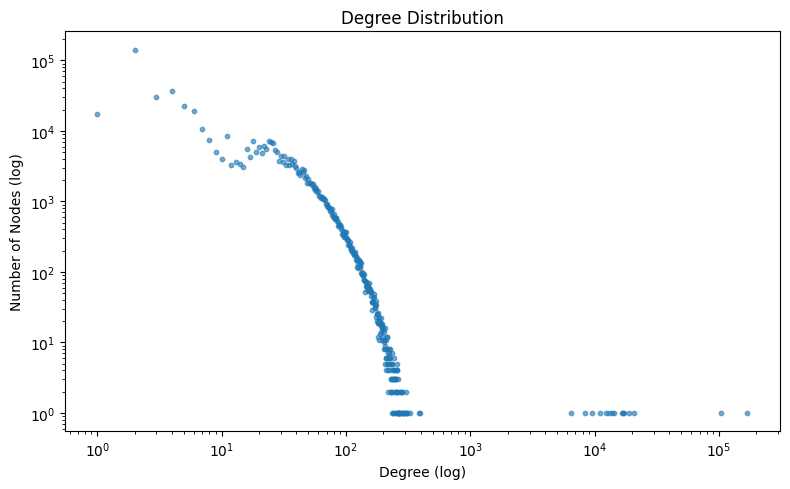

In [41]:
# PLOT DISTRIBUTION
degree_pd = degree_distribution.orderBy("degree").toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(degree_pd["degree"], degree_pd["count"], alpha=0.6, s=10)
plt.yscale("log")
plt.xscale("log")  # log-log é o standard para degree distribution
plt.xlabel("Degree (log)")
plt.ylabel("Number of Nodes (log)")
plt.title("Degree Distribution")
plt.tight_layout()
plt.show()

The graph shows a clear downward trend in log-log scale, confirming that the network follows a power law: the vast majority of accounts have very low degree (left side, high count) while a tiny number of accounts act as extreme hubs (right side, isolated dots).

The two isolated points on the far right (degree ~10k and ~170k) are the two suspicious accounts were already identified in the EDA — they are so far from the rest of the distribution that they stand out immediately, even visually.

The "knee" around degree 200-300 where the count drops to near 1 shows a clear separation between normal accounts and potential hub accounts. Accounts to the right of the knee exhibit anomalous degree values that are inconsistent with typical financial behavior and warrant further investigation. These accounts are strong candidates for money laundering activity, which will be validated against the is_laundering label in subsequent analyses.

In [54]:
degree_summary .join(laundering_sent, on="id", how="left") \
    .join(laundering_received, on="id", how="left") \
    .fillna(0) \
    .withColumn("is_suspicious",  
                F.when(F.col("laundering_sent") + F.col("laundering_received") > 0, 1).otherwise(0)) \
    .groupBy("is_suspicious") \
    .agg(
        F.round(F.mean("inDegree"), 2).alias("avg_inDegree"),
        F.round(F.mean("outDegree"), 2).alias("avg_outDegree"),
        F.round(F.mean("degree"), 2).alias("avg_degree"),
        F.percentile_approx("degree", 0.95).alias("p95_degree")
    ) \
    .show()

+-------------+------------+-------------+----------+----------+
|is_suspicious|avg_inDegree|avg_outDegree|avg_degree|p95_degree|
+-------------+------------+-------------+----------+----------+
|            1|       15.32|       132.23|    147.55|       107|
|            0|        9.82|         8.96|     18.78|        70|
+-------------+------------+-------------+----------+----------+



The results show a clear structural difference between suspicious and non-suspicious accounts in the transaction graph.

Suspicious accounts (`is_suspicious = 1`) have substantially higher connectivity than non-suspicious accounts across all degree metrics.

The strongest difference is observed in **out-degree**, where suspicious accounts send transactions to significantly more counterparties on average. This suggests that suspicious nodes behave primarily as **senders**, distributing funds across many destinations.

This pattern is consistent with common money laundering behaviours such as:
- rapid movement of funds,
- splitting transactions across multiple accounts (*smurfing*),
- or using intermediary accounts to disperse money through the network.

Overall, the degree analysis indicates that **transaction connectivity — especially out-degree — is a strong signal for identifying suspicious accounts** in the graph.

In [55]:
# CREATE HUBS
#
hubs = in_deg.join(out_deg, on="id", how="inner") \
             .withColumn("total_degree", F.col("inDegree") + F.col("outDegree")) \
             .orderBy(F.desc("total_degree"))

print("TOP 10 HUBS (alto in E out degree):")
hubs.show(10)

TOP 10 HUBS (alto in E out degree):


+------------+--------+---------+------------+
|          id|inDegree|outDegree|total_degree|
+------------+--------+---------+------------+
|70_100428660|    1084|   168672|      169756|
|70_1004286A8|     653|   103018|      103671|
|70_100428978|     150|    20497|       20647|
|70_1004286F0|     108|    18663|       18771|
|70_100428780|     117|    17264|       17381|
|70_1004289C0|     132|    16794|       16926|
|70_100428810|     114|    16426|       16540|
|70_1004287C8|     103|    14174|       14277|
|70_100428738|      98|    13756|       13854|
|70_100428A51|      28|    13073|       13101|
+------------+--------+---------+------------+
only showing top 10 rows



In [59]:
hubs.limit(20) \
    .join(laundering_sent,     on="id", how="left")\
    .join(laundering_received, on="id", how="left")\
    .fillna(0)\
    .withColumn("total_laundering", F.col("laundering_sent") + F.col("laundering_received"))\
    .withColumn("total_transactions", F.col("total_sent") + F.col("total_received"))\
    .withColumn("pct_laundering_total",
                F.round(F.col("total_laundering") / F.col("total_transactions") * 100, 2))\
    .orderBy(F.desc("total_degree"))\
    .show()

+--------------+--------+---------+------------+----------+---------------+-------------------+--------------+-------------------+-----------------------+----------------+------------------+--------------------+
|            id|inDegree|outDegree|total_degree|total_sent|laundering_sent|pct_laundering_sent|total_received|laundering_received|pct_laundering_received|total_laundering|total_transactions|pct_laundering_total|
+--------------+--------+---------+------------+----------+---------------+-------------------+--------------+-------------------+-----------------------+----------------+------------------+--------------------+
|  70_100428660|    1084|   168672|      169756|         0|              0|                0.0|          1084|                  0|                    0.0|               0|              1084|                 0.0|
|  70_1004286A8|     653|   103018|      103671|         0|              0|                0.0|           653|                  0|                    0.

In [60]:
laundering_sent.filter(F.col("id") == "70_100428660").show()

+------------+----------+---------------+-------------------+
|          id|total_sent|laundering_sent|pct_laundering_sent|
+------------+----------+---------------+-------------------+
|70_100428660|    168672|            243|               0.14|
+------------+----------+---------------+-------------------+



In [61]:
hubs.printSchema()
laundering_sent.printSchema()

root
 |-- id: string (nullable = false)
 |-- inDegree: long (nullable = false)
 |-- outDegree: long (nullable = false)
 |-- total_degree: long (nullable = false)

root
 |-- id: string (nullable = false)
 |-- total_sent: long (nullable = false)
 |-- laundering_sent: long (nullable = true)
 |-- pct_laundering_sent: double (nullable = true)



In [ ]:
degree_summary.unpersist()

# <font color='#2f94d7' size=5>**6.3. Page Rank**</font> <a class="anchor" id="6_3"></a>

[Back to TOC](#toc)

The core idea is: **a node is important if it is connected to other important nodes.**

Concretely, the algorithm works in rounds:

1. Every node starts with the same score (1/N, where N is the total number of nodes)
2. In each iteration, every node distributes its current score equally across all its outgoing edges
3. Each node's new score is the sum of what it received from its incoming edges, plus a small base amount from the random jump factor
4. Repeat for `maxIter` iterations

**Degree** simply counts how many edges touch a node. A node with 100 connections always has degree 100, regardless of whether those connections come from isolated nodes or from major hubs.

**PageRank** accounts for the quality of connections.


In [ ]:
# PAGE RANK
pagerank = g.pageRank(resetProbability=0.15, maxIter=10)

print("Top 20 accounts by PageRank:")
pagerank.vertices.orderBy(F.desc("pagerank")).show(20, truncate=False)

In [ ]:
# ANALYSE RELATIONSHIP BETWEEN PAGE RANK AND MONEY LAUNDERING
# Laundering ratio for sent transactions
laundering_sent = (
    g.edges
    .groupBy(F.col("src").alias("id"))
    .agg(
        F.count("*").alias("total_sent"),
        F.sum("is_laundering").alias("laundering_sent")
    )
    .withColumn("pct_laundering_sent", 
                F.round(F.col("laundering_sent") / F.col("total_sent") * 100, 2))
)

# Laundering ratio for received transactions
laundering_received = (
    g.edges
    .groupBy(F.col("dst").alias("id"))
    .agg(
        F.count("*").alias("total_received"),
        F.sum("is_laundering").alias("laundering_received")
    )
    .withColumn("pct_laundering_received",
                F.round(F.col("laundering_received") / F.col("total_received") * 100, 2))
)

# Join everything onto PageRank results
top20_pr = (
    pagerank.vertices
    .orderBy(F.desc("pagerank"))
    .limit(20)
    .join(laundering_sent,     on="id", how="left")
    .join(laundering_received, on="id", how="left")
    .fillna(0)
    .withColumn("total_transactions", 
                F.col("total_sent") + F.col("total_received"))
    .withColumn("total_laundering",
                F.col("laundering_sent") + F.col("laundering_received"))
    .withColumn("pct_laundering_total",
                F.round(F.col("total_laundering") / F.col("total_transactions") * 100, 2))
    .orderBy(F.desc("pagerank"))
)

top20_pr.select(
    "id",
    "pagerank",
    "total_sent",        "pct_laundering_sent",
    "total_received",    "pct_laundering_received",
    "total_transactions","pct_laundering_total"
).show(20, truncate=False)

In [ ]:
# CREATE HUBS
#
hubs = in_deg.join(out_deg, on="id", how="inner") \
             .withColumn("total_degree", F.col("inDegree") + F.col("outDegree")) \
             .orderBy(F.desc("total_degree"))

print("TOP 10 HUBS (alto in E out degree):")
hubs.show(10)